# Linear Regression with House Prices

This notebook walks through a simple linear regression workflow using the House Prices dataset. It starts with data inspection, builds a baseline model, evaluates its performance, and then compares a manually implemented gradient descent approach with scikit-learn.

In [93]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
train = pd.read_csv('data/raw/train (1).csv')
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [95]:
train.shape

(1460, 81)

In [96]:
train.isnull().sum().sort_values(ascending=False).head(20)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
Condition2         0
dtype: int64

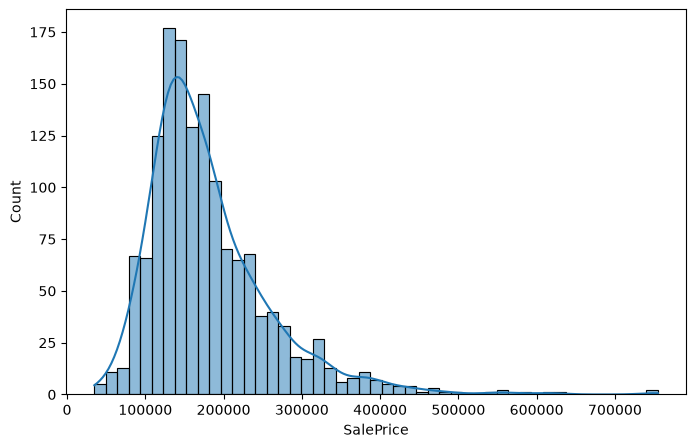

In [97]:
plt.figure(figsize=(8,5))
sns.histplot(train["SalePrice"], kde=True)
plt.show()

In [98]:
corr = train.corr(numeric_only=True)

corr["SalePrice"].sort_values(ascending=False).head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

In [99]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath"
]

X = train[features]

# Select the main features for the baseline model

These columns are chosen because they are strong predictors of house price in the dataset. The model will use them to learn a relationship between these features and the target variable, SalePrice.

In [100]:
X

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath
0,7,1710,2,856,2
1,6,1262,2,1262,2
2,7,1786,2,920,2
3,7,1717,3,756,1
4,8,2198,3,1145,2
...,...,...,...,...,...
1455,6,1647,2,953,2
1456,6,2073,2,1542,2
1457,7,2340,1,1152,2
1458,5,1078,1,1078,1


In [101]:
X.isnull().sum()

OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
FullBath       0
dtype: int64

In [102]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    train["SalePrice"],
    test_size=0.2,
    random_state=42
)


# Split data into training and testing sets

This step creates a train/test split so the model can be evaluated on unseen data. The test set helps us estimate how well the model generalizes, rather than just how well it fits the training data.

In [103]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[23602.16, 41.95,19334.18, 28.59, 1822.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['OverallQual','GrLivArea','GarageCars','TotalBsmtSF','FullBath']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9.479e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)


# Train the linear regression model

Here the regression model learns the relationship between the input features and the target variable. Once fitted, it can be used to predict sale prices for new examples.

In [104]:
predictions = model.predict(x_test)

# Generate predictions on the test set

These predictions allow us to compare the model’s output against the actual house prices in the test data.

In [105]:
mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 25453.164030300733


# Evaluate the model with MAE

Mean absolute error measures the average absolute difference between predicted and actual values. Lower values indicate better predictive accuracy.

In [106]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 40051.20363884138


In [107]:
r2 = r2_score(y_test, predictions)

print("R²:", r2)

R²: 0.7908695315439265


In [108]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
0,OverallQual,23602.164826
2,GarageCars,19334.176381
4,FullBath,1822.113765
1,GrLivArea,41.950117
3,TotalBsmtSF,28.589736


In [109]:
X_single = train["GrLivArea"].values
y_single = train["SalePrice"].values

In [110]:
X_single = (X_single - X_single.mean()) / X_single.std()

In [111]:
m = 0
b = 0

learning_rate = 0.01
epochs = 5000

n = len(X_single)

# Manual gradient descent example

This section implements linear regression from scratch using gradient descent. It is useful for understanding the math behind the algorithm, even though scikit-learn handles this more efficiently in practice.

In [112]:
for epoch in range(epochs):

    y_pred = m * X_single + b

    dm = (-2/n) * np.sum(X_single * (y_single - y_pred))
    db = (-2/n) * np.sum(y_single - y_pred)

    m = m - learning_rate * dm
    b = b - learning_rate * db

In [113]:
print("Slope:", m)
print("Intercept:", b)

Slope: 56275.6197272207
Intercept: 180921.19589041025


In [114]:
manual_preds = m * X_single + b

In [115]:
r2_manual = r2_score(y_single, manual_preds)

print("Manual R²:", r2_manual)

Manual R²: 0.5021486502718042


In [116]:
from sklearn.linear_model import LinearRegression

X_compare = train[["GrLivArea"]]

model = LinearRegression()

model.fit(X_compare, y_single)

print("Sklearn Coef:", model.coef_[0])
print("Sklearn Intercept:", model.intercept_)

Sklearn Coef: 107.13035896582514
Sklearn Intercept: 18569.025856487307


In [117]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt"
]

# Add more features and improve the model

This section expands the feature set to include another important predictor, YearBuilt. It also prepares the data for a stronger regression model by handling missing values.

In [118]:
features

['OverallQual',
 'GrLivArea',
 'GarageCars',
 'TotalBsmtSF',
 'FullBath',
 'YearBuilt']

In [119]:
X = train[features]

In [120]:
X.isnull().sum()

OverallQual    0
GrLivArea      0
GarageCars     0
TotalBsmtSF    0
FullBath       0
YearBuilt      0
dtype: int64

In [121]:
X = X.fillna(X.median())

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    train["SalePrice"],
    test_size=0.2,
    random_state=42
)

In [123]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[20507.2 , 51.99,15329.41, 24.48,-5421.21, 350.91]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['OverallQual','GrLivArea','GarageCars','TotalBsmtSF','FullBath', 'YearBuilt']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-7.599e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [125]:
predictions = model.predict(X_test)

In [126]:
mae = mean_absolute_error(y_test, predictions)
mae

25319.860444313614

In [127]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))
rmse

np.float64(39710.99035385876)

In [128]:
r2= r2_score(y_test, predictions)
r2

0.7944073417103639

In [129]:
X["GrLivArea_Squared"] = X["GrLivArea"] ** 2

# Add a squared feature for non-linearity

A squared term can help capture curved relationships in the data. This is a simple way to test whether adding a non-linear feature improves the model.

In [ ]:
X["GrLivArea_Squared"] = X["GrLivArea"] ** 2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    train["SalePrice"],
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

r2_score(y_test, predictions)

0.7123661624840137

# House Prices Regression Analysis

## Project Overview

This project explores the House Prices dataset using Linear Regression to predict residential property sale prices. The objective was to understand the complete machine learning workflow, including data preparation, exploratory data analysis (EDA), model training, evaluation, and feature engineering.

---

## Dataset

**Dataset:** House Prices - Advanced Regression Techniques

**Target Variable:**

* `SalePrice` → Final sale price of each house

**Selected Features:**

* `OverallQual` → Overall material and finish quality
* `GrLivArea` → Above-ground living area (square feet)
* `GarageCars` → Garage capacity in number of cars
* `TotalBsmtSF` → Total basement area (square feet)
* `FullBath` → Number of full bathrooms
* `YearBuilt` → Original construction year

---

## Step 1: Data Loading

The dataset was loaded into a Pandas DataFrame and inspected to understand its structure and available features.

```python
train = pd.read_csv("train.csv")
```

---

## Step 2: Exploratory Data Analysis (EDA)

The following analyses were performed:

### Dataset Inspection

* Checked dataset dimensions
* Reviewed column names and data types

### Missing Value Analysis

```python
X.isnull().sum()
```

Purpose:

* Identify incomplete records
* Ensure compatibility with Linear Regression

### Correlation Analysis

Examined relationships between numerical features and `SalePrice`.

Strongly correlated features included:

* OverallQual
* GrLivArea
* GarageCars
* TotalBsmtSF

---

## Step 3: Feature Selection

Selected six meaningful features believed to influence house prices.

```python
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt"
]
```

Input matrix:

```python
X = train[features]
```

Target variable:

```python
y = train["SalePrice"]
```

---

## Step 4: Train-Test Split

The dataset was divided into training and testing sets.

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
```

### Why?

* Training Set (80%) → Used for learning patterns
* Testing Set (20%) → Used for evaluating performance

This prevents data leakage and provides a realistic assessment of model accuracy.

---

## Step 5: Linear Regression Model

Created and trained a Linear Regression model.

```python
model = LinearRegression()
model.fit(X_train, y_train)
```

The model learns a relationship of the form:

Price = b + w₁x₁ + w₂x₂ + ... + wₙxₙ

Where:

* `b` = intercept
* `w` = feature coefficients

---

## Step 6: Predictions

Generated predictions on unseen test data.

```python
predictions = model.predict(X_test)
```

The model estimated house prices based on the selected features.

---

## Step 7: Model Evaluation

Three evaluation metrics were used.

### Mean Absolute Error (MAE)

```python
mean_absolute_error(y_test, predictions)
```

Measures average prediction error.

Lower values indicate better performance.

---

### Root Mean Squared Error (RMSE)

```python
np.sqrt(mean_squared_error(y_test, predictions))
```

Penalizes large prediction errors more heavily than MAE.

Lower values indicate better performance.

---

### R² Score

```python
r2_score(y_test, predictions)
```

Measures how much variation in house prices is explained by the model.

Interpretation:

* 1.00 = Perfect fit
* 0.90+ = Excellent
* 0.80+ = Strong
* 0.50 = Moderate
* 0.00 = No predictive power

---

## Step 8: Feature Engineering

Created a polynomial feature:

```python
X["GrLivArea_Squared"] = X["GrLivArea"] ** 2
```

### Purpose

Linear Regression assumes straight-line relationships.

Some real-world relationships are curved.

By adding:

```text
GrLivArea²
```

the model gains the ability to capture nonlinear patterns between living area and house price.

---

## Step 9: Model Retraining

After adding the polynomial feature:

1. Re-split the dataset
2. Retrained the model
3. Re-evaluated performance

The new R² score was compared with the original score to determine whether the engineered feature improved predictive power.

---

## Key Concepts Learned

### Features (X)

Variables used to make predictions.

Examples:

* OverallQual
* GrLivArea
* GarageCars

---

### Target Variable (y)

The value being predicted.

Example:

* SalePrice

---

### Training

The process where the model learns relationships from historical data.

---

### Prediction

Using learned patterns to estimate values for unseen data.

---

### Feature Engineering

Creating new variables from existing data to improve model performance.

---

### Overfitting

When a model memorizes training data and performs poorly on new data.

---

### Underfitting

When a model is too simple and fails to capture important relationships.

---

## Technologies Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-Learn
* Jupyter Notebook
* Git & GitHub

---

## Conclusion

This project demonstrated the complete machine learning workflow using Linear Regression. The analysis included data exploration, feature selection, model training, performance evaluation, and feature engineering. Through this exercise, key concepts such as regression modeling, MAE, RMSE, R², train-test splitting, and polynomial features were explored and applied to a real-world housing dataset.
